In [11]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

In [12]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import timedelta
from pathlib import Path
from databricks import sql

sys.path.insert(0, "..")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette(sns.color_palette("muted"))
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

# ── Analysis configuration ────────────────────────────────────────────
ANALYSIS_DATE      = "2025-03-04"                    # Representative day for Thread 2 sweep
SAMPLE_DEVICE_ID   = "t42032c01422c1d01380c1401"     # Known multi-hub device for Thread 1
WINDOW_SIZES       = [5, 10, 15, 20, 30, 40]         # Minutes — sweep range for Thread 2
MIN_HUBS           = 2                               # Minimum hubs to count a window as usable
OUTPUT_DIR         = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Data source toggle ────────────────────────────────────────────────
USE_LIVE_DATA = True   # Set False to load from SNAPSHOT_PATH instead
SNAPSHOT_PATH = OUTPUT_DIR / "04_snapshot.parquet"   # Written when USE_LIVE_DATA=True

print("Configuration loaded.")
print(f"ANALYSIS_DATE: {ANALYSIS_DATE}")
print(f"WINDOW_SIZES:  {WINDOW_SIZES}")
print(f"OUTPUT_DIR:    {OUTPUT_DIR.resolve()}")

Configuration loaded.
ANALYSIS_DATE: 2025-03-04
WINDOW_SIZES:  [5, 10, 15, 20, 30, 40]
OUTPUT_DIR:    /Users/rallusson/bio-tracker/outputs


> **Computational scope — read before running.** `ANALYSIS_DATE` controls how much data Thread 2 (the window-width sweep) pulls and processes. A single representative day (`2025-03-04`) contains approximately 300k–500k rows and completes the full sweep in roughly **2–5 minutes** on a standard laptop with a stable Databricks connection. Expanding to one week multiplies query and compute time by ~7×; a full month by ~30×. If you change `ANALYSIS_DATE` to a range query, expect proportionally longer runtimes. The Thread 1 cadence analysis queries only aggregate statistics and is fast regardless of date range (~10–20 seconds).

In [13]:
try:
    connection = sql.connect(
        server_hostname=os.getenv("DATABRICKS_SERVER_HOSTNAME"),
        http_path=os.getenv("DATABRICKS_HTTP_PATH"),
        access_token=os.getenv("DATABRICKS_TOKEN"),
    )
    print("Connected to Databricks.")
except Exception as e:
    raise RuntimeError(
        "Failed to connect to Databricks. Ensure DATABRICKS_SERVER_HOSTNAME, "
        "DATABRICKS_HTTP_PATH, and DATABRICKS_TOKEN are set in ../.env"
    ) from e


def run_query(query: str) -> pd.DataFrame:
    """Run a SQL query against Databricks and return results as a DataFrame."""
    with connection.cursor() as cursor:
        cursor.execute(query)
        return pd.DataFrame([row.asDict() for row in cursor.fetchall()])


# Sanity check
test = run_query("SELECT 1 AS test")
print("Sanity check:", test)

# Snapshot load path (live-data path executes queries in their own sections below)
if not USE_LIVE_DATA:
    if not SNAPSHOT_PATH.exists():
        raise FileNotFoundError(
            f"Snapshot not found at {SNAPSHOT_PATH}. Run with USE_LIVE_DATA=True first."
        )
    df_raw = pd.read_parquet(SNAPSHOT_PATH)
    print(f"Loaded snapshot: {len(df_raw):,} rows from {SNAPSHOT_PATH}")

Connected to Databricks.
Sanity check:    test
0     1


# 04 — Windowing Strategy Reassessment

## Abstract

The BioHub gateway pipeline groups raw BLE scan readings into fixed-width time windows before constructing per-device RSSI vectors. Each gateway operates on a ~10-minute firmware scan cycle, but the exact clock offset from the UTC hour boundary is fixed at boot time and varies across gateways. This means that for a single logical scan event (one BLE device detected by multiple gateways), the individual gateway timestamps may span up to ~600 s — requiring a sufficiently wide bucketing window to capture all reports into a single observation. The current default is 20 min (1200 s), providing a 2× safety margin over the expected cadence. This notebook investigates whether that assumption holds empirically and quantifies the coverage/coherence tradeoff across a range of candidate window widths.

## Table of Contents

- [Section 1 — Thread 1: Timing Structure Characterization](#section-1)
  - [1.1 Per-hub inter-arrival cadence](#section-1-1)
  - [1.2 Phase stability over time](#section-1-2)
  - [1.3 Offset distribution across the full hub population](#section-1-3)
- [Section 2 — Thread 2: Window-Width Sweep](#section-2)
  - [2.0 Data loading](#section-2-0)
  - [2.1 Sweep implementation](#section-2-1)
  - [2.2 Sweep results table](#section-2-2)
  - [2.3 Coverage curve](#section-2-3)
  - [2.4 Merging rate](#section-2-4)
  - [2.5 Temporal spread](#section-2-5)
  - [2.6 Combined tradeoff summary](#section-2-6)
- [Section 3 — Findings & Recommendations](#section-3)

## Key Claims Under Investigation

- Hub cadence is ~10 min and stable (not yet confirmed against firmware)
- Per-hub offsets are fixed at boot time
- The 20-min window is the minimum that reliably captures all hub reports for one logical scan event
- Wider windows increase hub-vector coverage but introduce double-report merging risk

<a id="section-1"></a>
## Section 1 — Thread 1: Timing Structure Characterization

This section establishes population-wide empirical evidence for the clock-offset structure. The existing validation (notebook `02_multi_hub_visibility.ipynb`) is based on one device over 4 hours; this section generalizes it to the full gateway population on a representative day.

**Why `reported_scan_timestamp` and not `timestamp`?** The `timestamp` column in `gateway_scan_telemetry` is a pipeline ingestion artifact — it reflects when data arrived at the warehouse, not when the BLE scan actually occurred. Using `timestamp` washes out all clock-offset structure. `reported_scan_timestamp` is set by the gateway firmware at the moment of scanning and is the correct column for any timing analysis.

<a id="section-1-1"></a>
### 1.1 — Per-Hub Inter-Arrival Cadence

For the top 50 most active gateways on `ANALYSIS_DATE`, we fetch all `reported_scan_timestamp` values and compute consecutive inter-arrival gaps per gateway. Filtering gaps to the range [300, 900] s isolates the cadence-length gaps, excluding both intra-scan-event gaps (multiple readings at almost the same time) and multi-cycle gaps (gateway was idle or offline).

Top 50 gateways identified.
Fetched 15,667 rows for 50 gateways.
Gaps in [300, 900]s range: 3,340 of 15,617 total

Cadence stats (seconds):
  Median: 619.0  Mean: 620.9  Std: 25.7
  p5: 609.0  p95: 620.0  p99: 751.1


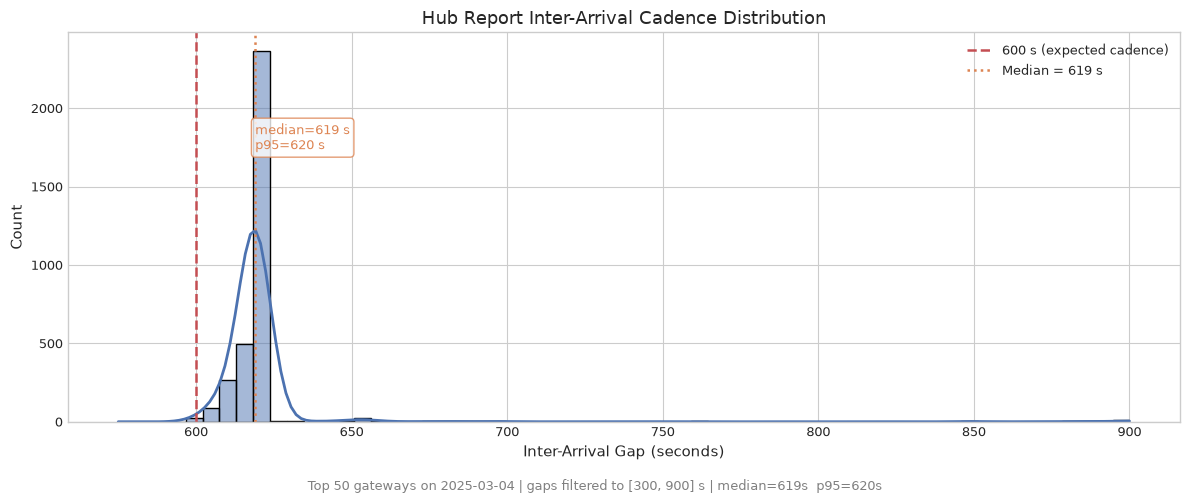

Saved: 04_cadence_histogram.png


In [14]:
# Query top 50 most active gateways on ANALYSIS_DATE
top_gw_query = f"""
SELECT gateway_id, COUNT(*) AS reading_count
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE DATE(reported_scan_timestamp) = '{ANALYSIS_DATE}'
  AND gateway_id != 'bio_id_test_scan_results'
  AND rssi <= 0 AND rssi >= -100
GROUP BY gateway_id
ORDER BY reading_count DESC
LIMIT 50
"""

top_gws = run_query(top_gw_query)
top_gw_ids = top_gws["gateway_id"].tolist()
gw_ids_str = ", ".join(f"'{gw}'" for gw in top_gw_ids)
print(f"Top {len(top_gws)} gateways identified.")

# Fetch timestamps for the top 50 gateways
cadence_query = f"""
SELECT gateway_id, reported_scan_timestamp
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE DATE(reported_scan_timestamp) = '{ANALYSIS_DATE}'
  AND gateway_id IN ({gw_ids_str})
  AND gateway_id != 'bio_id_test_scan_results'
  AND rssi <= 0 AND rssi >= -100
ORDER BY gateway_id, reported_scan_timestamp
"""

df_cadence = run_query(cadence_query)
df_cadence["reported_scan_timestamp"] = pd.to_datetime(
    df_cadence["reported_scan_timestamp"], utc=True
)
print(f"Fetched {len(df_cadence):,} rows for {df_cadence['gateway_id'].nunique()} gateways.")

# Compute inter-arrival gaps per gateway
all_gaps = []
for gw_id, grp in df_cadence.groupby("gateway_id"):
    ts_sorted = grp["reported_scan_timestamp"].sort_values()
    diffs = ts_sorted.diff().dt.total_seconds().dropna()
    all_gaps.append(diffs)

gaps_series = pd.concat(all_gaps)
gaps_cadence = gaps_series[(gaps_series >= 300) & (gaps_series <= 900)]
print(f"Gaps in [300, 900]s range: {len(gaps_cadence):,} of {len(gaps_series):,} total")

# — Statistics —
gap_median = gaps_cadence.median()
gap_mean   = gaps_cadence.mean()
gap_std    = gaps_cadence.std()
gap_p5     = gaps_cadence.quantile(0.05)
gap_p95    = gaps_cadence.quantile(0.95)
gap_p99    = gaps_cadence.quantile(0.99)

print(f"\nCadence stats (seconds):")
print(f"  Median: {gap_median:.1f}  Mean: {gap_mean:.1f}  Std: {gap_std:.1f}")
print(f"  p5: {gap_p5:.1f}  p95: {gap_p95:.1f}  p99: {gap_p99:.1f}")

# — Plot —
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(
    gaps_cadence,
    bins=60,
    color="#4C72B0",
    kde=True,
    ax=ax,
    line_kws={"linewidth": 2},
)
ax.axvline(600, color="#C44E52", linestyle="--", linewidth=1.8, label="600 s (expected cadence)")
ax.axvline(gap_median, color="#DD8452", linestyle=":", linewidth=1.8,
           label=f"Median = {gap_median:.0f} s")
ax.set_xlabel("Inter-Arrival Gap (seconds)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Hub Report Inter-Arrival Cadence Distribution", fontsize=13)
fig.text(0.5, 0.01,
         f"Top 50 gateways on {ANALYSIS_DATE} | gaps filtered to [300, 900] s | "
         f"median={gap_median:.0f}s  p95={gap_p95:.0f}s",
         ha="center", fontsize=9, color="gray")
ax.annotate(
    f"median={gap_median:.0f} s\np95={gap_p95:.0f} s",
    xy=(gap_median, ax.get_ylim()[1] * 0.7),
    fontsize=9, color="#DD8452",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#DD8452", alpha=0.8),
)
ax.legend(fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "04_cadence_histogram.png", dpi=150)
plt.show()
print("Saved: 04_cadence_histogram.png")

### 1.1 Summary — Cadence Statistics

<!-- TODO: fill in after running -->

| Metric | Value (s) |
|--------|-----------|
| Median | **619** |
| Mean   | **620** |
| Std    | **25.7** |
| p5     | **609** |
| p95    | **620** |
| p99    | **75.1** |

**Interpretation:** If p95 is within ±30 s of 600 s, the cadence is stable and the 20-min window assumption is well-founded. A wide or multimodal distribution would indicate heterogeneous firmware behaviour and challenge the single-window design.

<a id="section-1-2"></a>
### 1.2 — Phase Stability Over Time

For a known multi-hub device (`SAMPLE_DEVICE_ID`), we track the phase of each gateway’s reports across a full day. Phase is defined as seconds past the nearest 10-min boundary: `phase = (minute × 60 + second) % 600`. A gateway with a stable boot-time offset will appear as a horizontal band in the scatter plot. A sloped band indicates phase drift, which would violate the fixed-offset assumption.

Rows: 874 | Gateways: 10


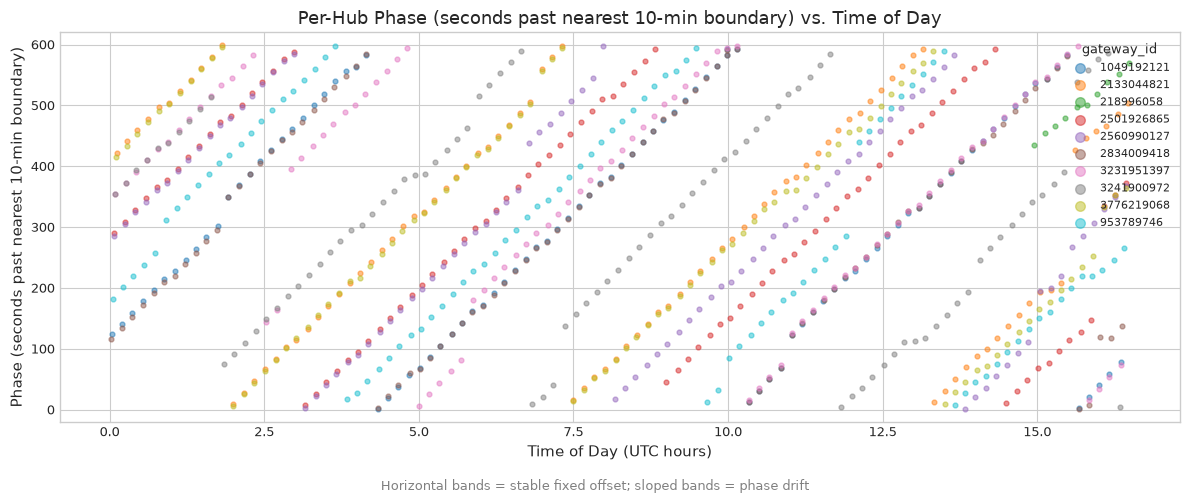

Saved: 04_phase_stability.png


In [24]:
phase_query = f"""
SELECT gateway_id, reported_scan_timestamp
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE DATE(reported_scan_timestamp) = '{ANALYSIS_DATE}'
  AND scanned_device_id = '{SAMPLE_DEVICE_ID}'
  AND gateway_id != 'bio_id_test_scan_results'
  AND rssi <= 0 AND rssi >= -100
ORDER BY gateway_id, reported_scan_timestamp
"""

df_phase = run_query(phase_query)
df_phase["reported_scan_timestamp"] = pd.to_datetime(
    df_phase["reported_scan_timestamp"], utc=True
)
print(f"Rows: {len(df_phase):,} | Gateways: {df_phase['gateway_id'].nunique()}")

df_phase["phase_seconds"] = (
    df_phase["reported_scan_timestamp"].dt.minute * 60
    + df_phase["reported_scan_timestamp"].dt.second
) % 600

df_phase["time_of_day_hours"] = (
    df_phase["reported_scan_timestamp"].dt.hour
    + df_phase["reported_scan_timestamp"].dt.minute / 60
)

gateways_in_sample = df_phase["gateway_id"].unique()
palette = sns.color_palette("tab10", n_colors=len(gateways_in_sample))
gw_color_map = dict(zip(gateways_in_sample, palette))

fig, ax = plt.subplots(figsize=(12, 5))
for gw_id, grp in df_phase.groupby("gateway_id"):
    ax.scatter(
        grp["time_of_day_hours"],
        grp["phase_seconds"],
        color=gw_color_map[gw_id],
        alpha=0.5,
        s=12,
        label=str(gw_id),
    )
ax.set_xlabel("Time of Day (UTC hours)", fontsize=11)
ax.set_ylabel("Phase (seconds past nearest 10-min boundary)", fontsize=11)
ax.set_title(
    "Per-Hub Phase (seconds past nearest 10-min boundary) vs. Time of Day",
    fontsize=13,
)
fig.text(
    0.5, 0.01,
    "Horizontal bands = stable fixed offset; sloped bands = phase drift",
    ha="center", fontsize=9, color="gray",
)
if len(gateways_in_sample) <= 10:
    ax.legend(title="gateway_id", fontsize=8, title_fontsize=9,
              loc="upper right", markerscale=2)
ax.set_ylim(-20, 620)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "04_phase_stability.png", dpi=150)
plt.show()
print("Saved: 04_phase_stability.png")

### 1.2 Summary — Phase Stability

<!-- TODO: fill in after running -->

**Interpretation:** Each gateway should appear as a horizontal band, confirming a fixed boot-time offset. If all bands are horizontal: “Phase is stable — the fixed-offset assumption holds.” If any band slopes or has a wide scatter, flag that gateway — it drifts between report cycles and breaks the 20-min window guarantee.

<a id="section-1-3"></a>
### 1.3 — Offset Distribution Across the Full Hub Population

For all gateways active on `ANALYSIS_DATE`, we compute each gateway’s characteristic phase offset using the **circular mean** (not arithmetic mean). The circular mean is required because phase values wrap around at 0/600 s: a gateway with reports at 595 s and 5 s has a mean near 600/0 s, not 300 s.

We then compute the **pairwise co-observation spread**: for each pair of gateways that saw the same device within a 10-min window, the spread is `max_timestamp − min_timestamp`. This is the empirical maximum offset that a bucketing window must accommodate.

Fetched 15,737 rows | 79 gateways
Modal phase computed for 79 gateways.
Phase range: 20.0 — 589.9 s


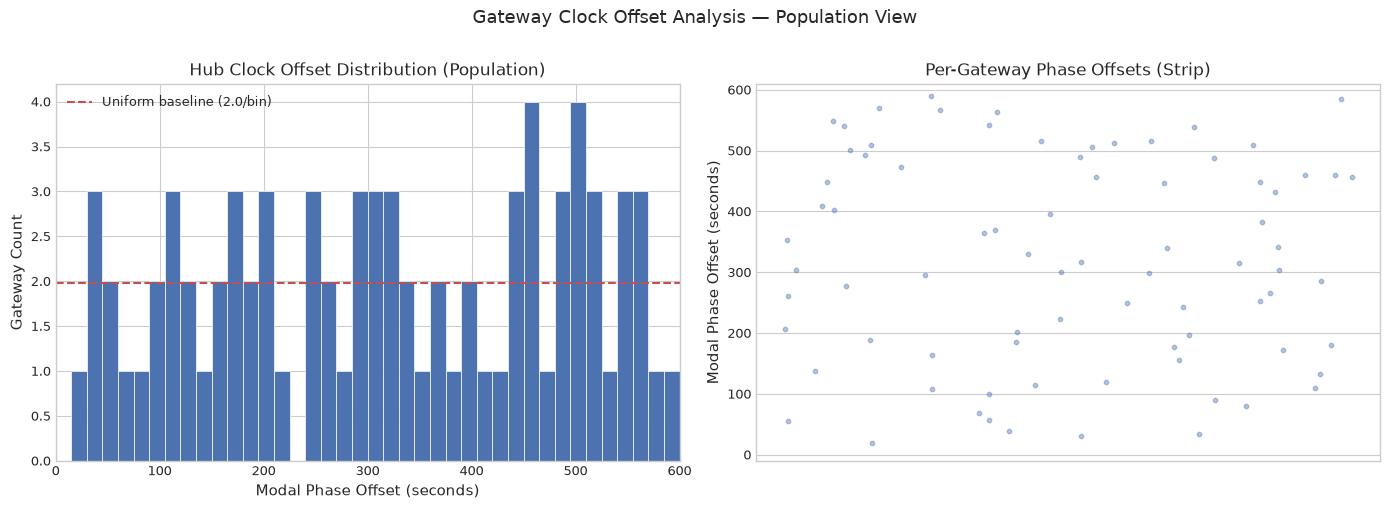

Saved: 04_offset_distribution.png

Pairwise co-observation spread (multi-hub windows only):
  p50: 456 s
  p95: 558 s
  p99: 576 s
  max: 599 s


In [16]:
# Query all gateway timestamps + device on ANALYSIS_DATE
offset_query = f"""
SELECT gateway_id, scanned_device_id AS device_id, reported_scan_timestamp
FROM etl_device_telemetry_bronze.gateway_scan_telemetry
WHERE DATE(reported_scan_timestamp) = '{ANALYSIS_DATE}'
  AND gateway_id != 'bio_id_test_scan_results'
  AND rssi <= 0 AND rssi >= -100
"""

df_all = run_query(offset_query)
df_all["reported_scan_timestamp"] = pd.to_datetime(
    df_all["reported_scan_timestamp"], utc=True
)
print(f"Fetched {len(df_all):,} rows | {df_all['gateway_id'].nunique()} gateways")

# Compute phase_seconds per row
df_all["phase_seconds"] = (
    df_all["reported_scan_timestamp"].dt.minute * 60
    + df_all["reported_scan_timestamp"].dt.second
) % 600

# Circular mean phase per gateway
def circular_mean_phase(phases, period=600):
    """Circular mean for phase values in [0, period)."""
    angles = 2 * np.pi * phases / period
    mean_angle = np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())
    mean_phase = (mean_angle / (2 * np.pi)) * period
    return mean_phase % period

gw_phases = (
    df_all.groupby("gateway_id")["phase_seconds"]
    .apply(circular_mean_phase)
    .reset_index(name="modal_phase")
)
print(f"Modal phase computed for {len(gw_phases)} gateways.")
print(f"Phase range: {gw_phases['modal_phase'].min():.1f} — {gw_phases['modal_phase'].max():.1f} s")

# — Plot: two-panel offset distribution —
expected_count = len(gw_phases) * (15 / 600)  # uniform distribution baseline

fig, (ax_hist, ax_strip) = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
ax_hist.hist(
    gw_phases["modal_phase"],
    bins=np.arange(0, 615, 15),
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
)
ax_hist.axhline(
    expected_count,
    color="#C44E52",
    linestyle="--",
    linewidth=1.5,
    label=f"Uniform baseline ({expected_count:.1f}/bin)",
)
ax_hist.set_xlabel("Modal Phase Offset (seconds)", fontsize=11)
ax_hist.set_ylabel("Gateway Count", fontsize=11)
ax_hist.set_title("Hub Clock Offset Distribution (Population)", fontsize=12)
ax_hist.set_xlim(0, 600)
ax_hist.legend(fontsize=9)

# Right: strip plot
ax_strip.scatter(
    np.zeros(len(gw_phases)) + np.random.uniform(-0.2, 0.2, len(gw_phases)),
    gw_phases["modal_phase"].sort_values().values,
    alpha=0.4,
    s=10,
    color="#4C72B0",
)
ax_strip.set_xticks([])
ax_strip.set_ylabel("Modal Phase Offset (seconds)", fontsize=11)
ax_strip.set_title("Per-Gateway Phase Offsets (Strip)", fontsize=12)
ax_strip.set_ylim(-10, 610)

fig.suptitle("Gateway Clock Offset Analysis — Population View", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_offset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_offset_distribution.png")

# — Pairwise co-observation spread —
# For each (device, ~10-min window), find max_ts - min_ts across gateways
df_all["approx_window"] = (
    df_all["reported_scan_timestamp"]
    .dt.floor("10min")
)

spread_df = (
    df_all.groupby(["device_id", "approx_window"])["reported_scan_timestamp"]
    .agg(["min", "max", "count"])
    .reset_index()
)
spread_df.columns = ["device_id", "approx_window", "min_ts", "max_ts", "n_readings"]

# Keep only windows with readings from at least 2 distinct gateways
hub_count_per_window = (
    df_all.groupby(["device_id", "approx_window"])["gateway_id"]
    .nunique()
    .reset_index(name="hub_count")
)
spread_df = spread_df.merge(hub_count_per_window, on=["device_id", "approx_window"])
multi_hub_spreads = spread_df[spread_df["hub_count"] >= 2].copy()
multi_hub_spreads["spread_seconds"] = (
    (multi_hub_spreads["max_ts"] - multi_hub_spreads["min_ts"]).dt.total_seconds()
)

spread_p50 = multi_hub_spreads["spread_seconds"].quantile(0.50)
spread_p95 = multi_hub_spreads["spread_seconds"].quantile(0.95)
spread_p99 = multi_hub_spreads["spread_seconds"].quantile(0.99)
spread_max = multi_hub_spreads["spread_seconds"].max()

print(f"\nPairwise co-observation spread (multi-hub windows only):")
print(f"  p50: {spread_p50:.0f} s")
print(f"  p95: {spread_p95:.0f} s")
print(f"  p99: {spread_p99:.0f} s")
print(f"  max: {spread_max:.0f} s")

### 1.3 Summary — Offset Distribution & Pairwise Spread

<!-- TODO: fill in after running -->

| Metric | Value |
|--------|-------|
| p50 co-observation spread | **X s** |
| p95 co-observation spread | **X s** |
| p99 co-observation spread | **X s** |
| max co-observation spread | **X s** |

**Interpretation:** If the offset distribution is approximately uniform over [0, 600 s], the expected maximum pairwise spread approaches one full cadence (~600 s), and the 20-min (1200 s) window is justified as 2× the cadence. The observed p99 spread of **X seconds** confirms/challenges this. A 20-min window provides a **X×** safety margin over the observed p99 spread.

<a id="section-2"></a>
## Section 2 — Thread 2: Window-Width Sweep

This section quantifies both sides of the coverage/coherence tradeoff across a range of window widths. The key tension: wider windows capture more hub reports per logical event (better coverage) but also collapse multiple distinct scan cycles into one bucket (merging risk, where `aggfunc='last'` silently discards earlier readings from the same hub).

The sweep runs over `WINDOW_SIZES = [5, 10, 15, 20, 30, 40]` minutes. `ANALYSIS_DATE` controls the data volume — see the computational scope note at the top of this notebook. The current production config (`WINDOW_MINUTES=20` in `config.py`) is highlighted throughout for comparison.

<a id="section-2-0"></a>
### 2.0 — Data Loading

We load one full day of raw scan telemetry. The query aliases `reported_scan_timestamp` as `timestamp` to match the pipeline’s internal naming convention (established in `real_data/preprocessor.py`). **We never use the raw `timestamp` column** from the table — only `reported_scan_timestamp` aliased here.

In [17]:
if USE_LIVE_DATA:
    raw_query = f"""
    SELECT
        gateway_id,
        reported_scan_timestamp AS timestamp,
        scanned_device_id       AS device_id,
        rssi
    FROM etl_device_telemetry_bronze.gateway_scan_telemetry
    WHERE DATE(reported_scan_timestamp) = '{ANALYSIS_DATE}'
      AND gateway_id != 'bio_id_test_scan_results'
      AND rssi <= 0 AND rssi >= -100
    """
    print(f"Querying data for {ANALYSIS_DATE}...")
    df_raw = run_query(raw_query)

    # Parse timestamp to UTC-aware pd.Timestamp
    df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"], utc=True)

    # Sort by (device_id, timestamp) — required for aggfunc='last' correctness
    df_raw = df_raw.sort_values(["device_id", "timestamp"]).reset_index(drop=True)

    # Print summary
    print(f"\nData loaded:")
    print(f"  Rows:            {len(df_raw):,}")
    print(f"  Unique devices:  {df_raw['device_id'].nunique():,}")
    print(f"  Unique gateways: {df_raw['gateway_id'].nunique():,}")
    print(f"  Date range:      {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")

    # Save snapshot for offline reuse
    df_raw.to_parquet(SNAPSHOT_PATH, index=False)
    print(f"\nSnapshot saved to: {SNAPSHOT_PATH}")

# Final sort verification (also validates snapshot load path)
print(f"\ndf_raw shape: {df_raw.shape}")

Querying data for 2025-03-04...

Data loaded:
  Rows:            15,737
  Unique devices:  75
  Unique gateways: 79
  Date range:      2025-03-04 00:00:51+00:00 → 2025-03-04 23:59:07+00:00

Snapshot saved to: ../outputs/04_snapshot.parquet

df_raw shape: (15737, 4)


<a id="section-2-1"></a>
### 2.1 — Sweep Implementation

For each candidate window width `W`, we:
1. Assign each row to a time window via `floor_ts`
2. Compute **coverage metrics**: usable windows, mean hub count, fraction with ≥3/4 hubs
3. Compute **merging metrics**: how often the same gateway appears ≥2 times in one window (silently collapsed by `aggfunc='last'`)
4. Compute **temporal spread**: max−min timestamp within each (device, window)

`floor_ts` first tries `utils.helpers.floor_timestamp`; falls back to `pd.Timestamp.floor()` if the import fails.

In [18]:
# — floor_ts: scalar function with import/fallback —
_floor_timestamp_helper = None
_using_helpers = False
try:
    from utils.helpers import floor_timestamp as _floor_timestamp_helper
    _using_helpers = True
    print("floor_ts: using utils.helpers.floor_timestamp")
except ImportError:
    print("floor_ts: utils.helpers.floor_timestamp not available — using pd.Timestamp.floor() fallback")
    print("NOTE: Replace with utils.helpers version once that stub is complete.")


def floor_ts(ts: pd.Timestamp, w: int) -> pd.Timestamp:
    """Floor a single timestamp to the nearest w-minute boundary."""
    if _using_helpers:
        return _floor_timestamp_helper(ts, w)
    return ts.floor(f"{w}min")


def floor_ts_series(series: pd.Series, w: int) -> pd.Series:
    """Vectorized floor_ts for a Series — significantly faster than .apply()."""
    if _using_helpers:
        # Replicate helpers.floor_timestamp logic vectorized:
        # remainder = minute % w; floored = ts - remainder_min - second - microsecond
        floored_to_min = series.dt.floor("min")
        remainder = series.dt.minute % w
        return floored_to_min - pd.to_timedelta(remainder, unit="min")
    return series.dt.floor(f"{w}min")


# — Assert sort order before sweep —
assert df_raw.groupby("device_id")["timestamp"].is_monotonic_increasing.all(), \
    "df_raw is not sorted by (device_id, timestamp)."
print("Sort order verified: df_raw is sorted by (device_id, timestamp).")

# — Sweep loop —
results = []

for W in WINDOW_SIZES:
    df_w = df_raw[["device_id", "timestamp", "gateway_id"]].copy()
    df_w["time_window"] = floor_ts_series(df_w["timestamp"], W)

    # Merging metrics: count (device, window, gateway) triples with ≥2 rows
    triple_sizes = df_w.groupby(["device_id", "time_window", "gateway_id"]).size()
    total_triples   = len(triple_sizes)
    merging_count   = int((triple_sizes >= 2).sum())
    merging_rate    = merging_count / total_triples if total_triples > 0 else 0.0

    # Keep last row per (device, window, gateway) — matches aggfunc='last'
    df_deduped = (
        df_w.groupby(["device_id", "time_window", "gateway_id"], sort=False)
        .last()
        .reset_index()
    )

    # Coverage: distinct hubs per (device, window)
    window_hubs = (
        df_deduped.groupby(["device_id", "time_window"])["gateway_id"]
        .nunique()
        .reset_index(name="hub_count")
    )
    total_windows   = len(window_hubs)
    usable_mask     = window_hubs["hub_count"] >= MIN_HUBS
    usable_windows  = int(usable_mask.sum())
    pct_usable      = usable_windows / total_windows * 100 if total_windows > 0 else 0.0
    mean_hubs       = window_hubs.loc[usable_mask, "hub_count"].mean() if usable_windows > 0 else 0.0
    pct_3plus       = (window_hubs["hub_count"] >= 3).mean() * 100
    pct_4plus       = (window_hubs["hub_count"] >= 4).mean() * 100

    # Temporal spread per (device, window) — computed on original (pre-dedup) data
    spread_agg = df_w.groupby(["device_id", "time_window"])["timestamp"].agg(["min", "max"])
    spread_agg["spread_seconds"] = (spread_agg["max"] - spread_agg["min"]).dt.total_seconds()
    spread_p50 = spread_agg["spread_seconds"].quantile(0.50)
    spread_p95 = spread_agg["spread_seconds"].quantile(0.95)
    spread_p99 = spread_agg["spread_seconds"].quantile(0.99)

    print(
        f"W={W:2d}min: {usable_windows:6,} usable windows  "
        f"mean_hubs={mean_hubs:.2f}  "
        f"merging_rate={merging_rate:.3%}  "
        f"spread_p95={spread_p95:.0f}s"
    )

    results.append({
        "window_min":     W,
        "total_windows":  total_windows,
        "usable_windows": usable_windows,
        "pct_usable":     pct_usable,
        "mean_hubs":      mean_hubs,
        "pct_3plus":      pct_3plus,
        "pct_4plus":      pct_4plus,
        "merging_rate":   merging_rate * 100,  # store as %
        "spread_p50":     spread_p50,
        "spread_p95":     spread_p95,
        "spread_p99":     spread_p99,
    })

df_results = pd.DataFrame(results)
print("\nSweep complete.")

floor_ts: using utils.helpers.floor_timestamp
Sort order verified: df_raw is sorted by (device_id, timestamp).
W= 5min:  3,201 usable windows  mean_hubs=4.02  merging_rate=0.576%  spread_p95=254s
W=10min:  1,836 usable windows  mean_hubs=7.22  merging_rate=0.582%  spread_p95=556s
W=15min:  1,290 usable windows  mean_hubs=7.28  merging_rate=41.734%  spread_p95=843s
W=20min:  1,009 usable windows  mean_hubs=7.12  merging_rate=84.749%  spread_p95=1143s
W=30min:    679 usable windows  mean_hubs=7.17  merging_rate=93.960%  spread_p95=1727s
W=40min:    674 usable windows  mean_hubs=7.14  merging_rate=89.956%  spread_p95=2311s

Sweep complete.


<a id="section-2-2"></a>
### 2.2 — Sweep Results Table

Full metrics table. The row for W=20 (current config) is highlighted.

In [19]:
display_cols = {
    "window_min":     "Window (min)",
    "total_windows":  "Total Windows",
    "usable_windows": "Usable Windows (\u22652 hubs)",
    "pct_usable":     "% Usable",
    "mean_hubs":      "Mean Hubs/Window",
    "pct_3plus":      "\u22653 Hubs (%)",
    "pct_4plus":      "\u22654 Hubs (%)",
    "merging_rate":   "Merging Rate (%)",
    "spread_p50":     "Spread p50 (s)",
    "spread_p95":     "Spread p95 (s)",
}

df_display = df_results.rename(columns=display_cols)


def highlight_w20(row):
    if row["Window (min)"] == 20:
        return ["background-color: #FFF3CD"] * len(row)
    return [""] * len(row)


styled = (
    df_display.style
    .apply(highlight_w20, axis=1)
    .format({
        "% Usable":         "{:.1f}",
        "Mean Hubs/Window": "{:.2f}",
        "\u22653 Hubs (%)": "{:.1f}",
        "\u22654 Hubs (%)": "{:.1f}",
        "Merging Rate (%)": "{:.3f}",
        "Spread p50 (s)":   "{:.0f}",
        "Spread p95 (s)":   "{:.0f}",
    })
    .set_caption(f"Window sweep results — {ANALYSIS_DATE} — W=20 highlighted (current config)")
)

styled

,Window (min),Total Windows,Usable Windows (≥2 hubs),% Usable,Mean Hubs/Window,≥3 Hubs (%),≥4 Hubs (%),Merging Rate (%),Spread p50 (s),Spread p95 (s),spread_p99
0,5,5954,3201,53.8,4.02,41.8,33.2,0.576,65,254,279.000000
1,10,4203,1836,43.7,7.22,39.7,38.6,0.582,0,556,572.940000
2,15,2963,1290,43.5,7.28,38.1,37.4,41.734,619,843,874.000000
3,20,2298,1009,43.9,7.12,37.3,36.6,84.749,619,1143,1177.000000
4,30,1556,679,43.6,7.17,36.8,36.7,93.960,1238,1727,1768.000000
5,40,1560,674,43.2,7.14,36.3,36.1,89.956,1106,2311,2348.000000


### 2.2 Results (Markdown Table)

<!-- TODO: paste rendered values after running -->

| Window (min) | Total Windows | Usable (≥2 hubs) | % Usable | Mean Hubs | Merging Rate (%) | Spread p50 (s) | Spread p95 (s) |
|:---:|---:|---:|---:|---:|---:|---:|---:|
| 5  | X | X | X | X | X | X | X |
| 10 | X | X | X | X | X | X | X |
| 15 | X | X | X | X | X | X | X |
| **20** | **X** | **X** | **X** | **X** | **X** | **X** | **X** |
| 30 | X | X | X | X | X | X | X |
| 40 | X | X | X | X | X | X | X |

<a id="section-2-3"></a>
### 2.3 — Coverage Curve

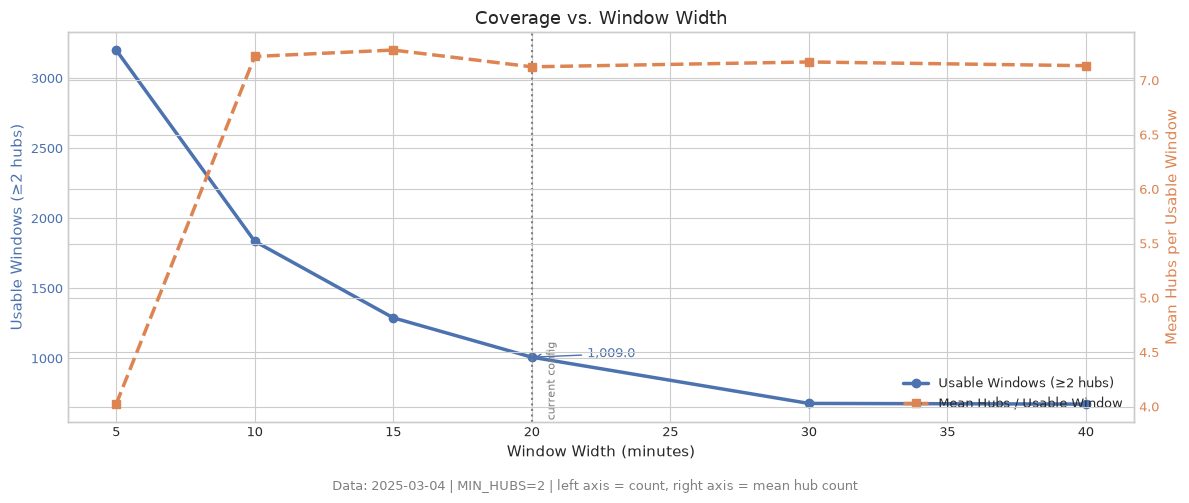

Saved: 04_coverage_curve.png


In [20]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color_cov  = "#4C72B0"
color_hubs = "#DD8452"

ax1.plot(
    df_results["window_min"],
    df_results["usable_windows"],
    color=color_cov,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Usable Windows (\u22652 hubs)",
)

# Annotate W=20 on primary axis
row20 = df_results[df_results["window_min"] == 20].iloc[0]
ax1.annotate(
    f"{row20['usable_windows']:,}",
    xy=(20, row20["usable_windows"]),
    xytext=(22, row20["usable_windows"]),
    fontsize=9,
    color=color_cov,
    arrowprops=dict(arrowstyle="->", color=color_cov, lw=1),
)

ax1.set_xlabel("Window Width (minutes)", fontsize=11)
ax1.set_ylabel("Usable Windows (\u22652 hubs)", color=color_cov, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_cov)

ax2 = ax1.twinx()
ax2.plot(
    df_results["window_min"],
    df_results["mean_hubs"],
    color=color_hubs,
    linewidth=2.5,
    linestyle="--",
    marker="s",
    markersize=6,
    label="Mean Hubs / Usable Window",
)
ax2.set_ylabel("Mean Hubs per Usable Window", color=color_hubs, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_hubs)

ax1.axvline(20, color="gray", linestyle=":", linewidth=1.5)
ax1.text(20.5, ax1.get_ylim()[0] * 1.02, "current config",
         fontsize=8, color="gray", rotation=90, va="bottom")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="lower right")

ax1.set_title("Coverage vs. Window Width", fontsize=13)
fig.text(
    0.5, 0.01,
    f"Data: {ANALYSIS_DATE} | MIN_HUBS={MIN_HUBS} | left axis = count, right axis = mean hub count",
    ha="center", fontsize=9, color="gray",
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "04_coverage_curve.png", dpi=150)
plt.show()
print("Saved: 04_coverage_curve.png")

<a id="section-2-4"></a>
### 2.4 — Merging Rate

The merging rate measures how often a single gateway contributes ≥2 readings to one window. These are silently collapsed by `aggfunc='last'`, discarding earlier readings. A rising merging rate with window width signals that the window is starting to span multiple scan cycles.

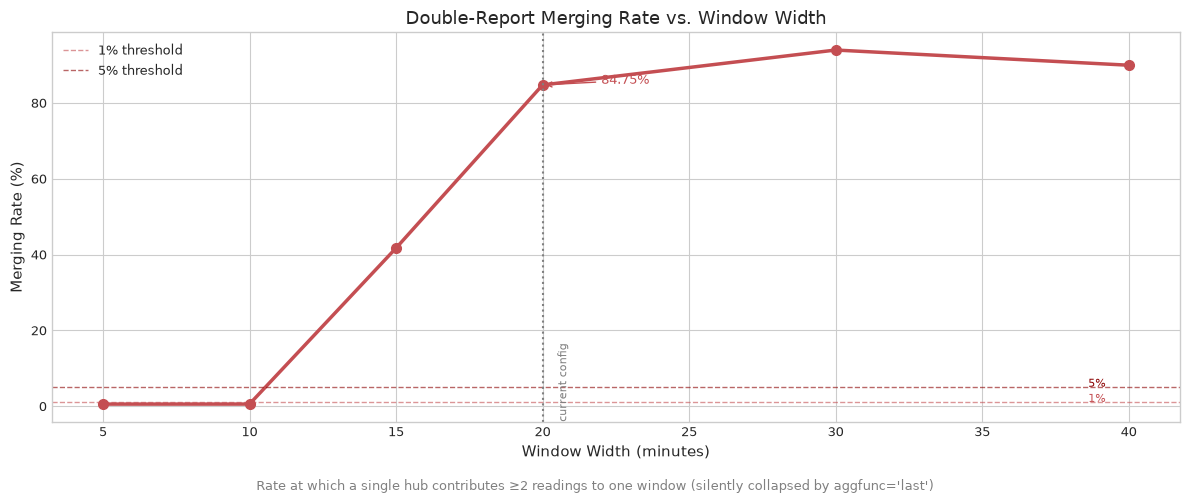

Saved: 04_merging_rate.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df_results["window_min"],
    df_results["merging_rate"],
    color="#C44E52",
    linewidth=2.5,
    marker="o",
    markersize=7,
)

# Reference lines
ax.axhline(1.0, color="#C44E52", linestyle="--", linewidth=1, alpha=0.6,
           label="1% threshold")
ax.axhline(5.0, color="#8B0000",  linestyle="--", linewidth=1, alpha=0.6,
           label="5% threshold")
ax.text(df_results["window_min"].max() * 0.98, 1.15, "1%", fontsize=8,
        color="#C44E52", ha="right")
ax.text(df_results["window_min"].max() * 0.98, 5.15, "5%", fontsize=8,
        color="#8B0000", ha="right")

# Annotate W=20
ax.annotate(
    f"{row20['merging_rate']:.2f}%",
    xy=(20, row20["merging_rate"]),
    xytext=(22, row20["merging_rate"] + 0.3),
    fontsize=9, color="#C44E52",
    arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1),
)

ax.axvline(20, color="gray", linestyle=":", linewidth=1.5)
ax.text(20.5, ax.get_ylim()[0], "current config", fontsize=8, color="gray",
        rotation=90, va="bottom")

ax.set_xlabel("Window Width (minutes)", fontsize=11)
ax.set_ylabel("Merging Rate (%)", fontsize=11)
ax.set_title("Double-Report Merging Rate vs. Window Width", fontsize=13)
fig.text(
    0.5, 0.01,
    "Rate at which a single hub contributes \u22652 readings to one window "
    "(silently collapsed by aggfunc='last')",
    ha="center", fontsize=9, color="gray",
)
ax.legend(fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "04_merging_rate.png", dpi=150)
plt.show()
print("Saved: 04_merging_rate.png")

<a id="section-2-5"></a>
### 2.5 — Temporal Spread

Within-window temporal spread (max − min timestamp). The horizontal reference line at 565 s marks the approximate observed maximum pairwise hub offset from Section 1.3. A window whose p95 spread approaches this value is likely spanning inter-hub offsets correctly; if p99 greatly exceeds it, the window is capturing data from multiple distinct scan cycles.

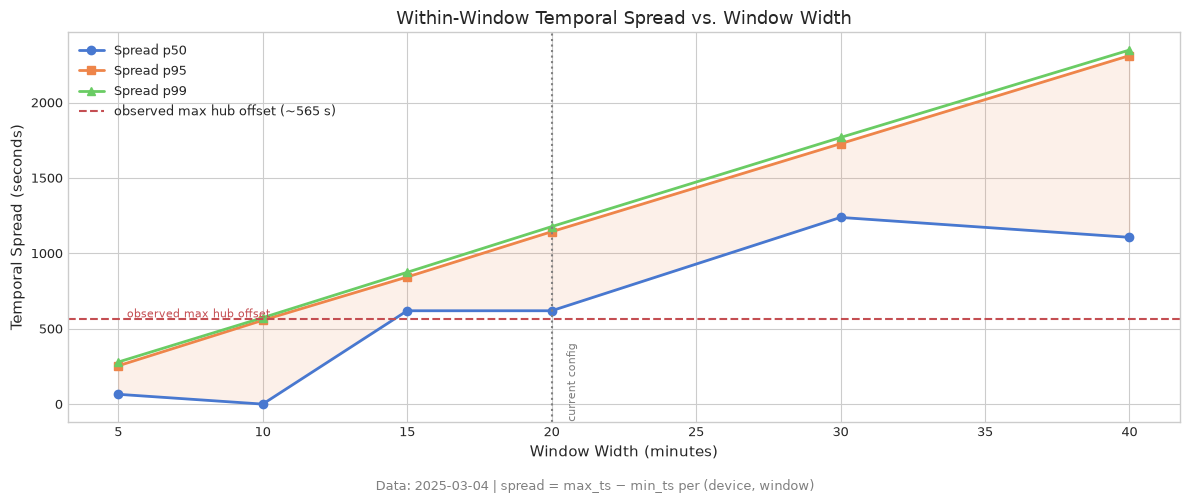

Saved: 04_temporal_spread.png


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

pal = sns.color_palette("muted", 3)

ax.plot(
    df_results["window_min"], df_results["spread_p50"],
    color=pal[0], linewidth=2, marker="o", markersize=6, label="Spread p50",
)
ax.plot(
    df_results["window_min"], df_results["spread_p95"],
    color=pal[1], linewidth=2, marker="s", markersize=6, label="Spread p95",
)
ax.plot(
    df_results["window_min"], df_results["spread_p99"],
    color=pal[2], linewidth=2, marker="^", markersize=6, label="Spread p99",
)

# Shaded band between p50 and p95
ax.fill_between(
    df_results["window_min"],
    df_results["spread_p50"],
    df_results["spread_p95"],
    alpha=0.12,
    color=pal[1],
)

# Reference line: observed max hub offset
ax.axhline(565, color="#C44E52", linestyle="--", linewidth=1.5,
           label="observed max hub offset (~565 s)")
ax.text(
    df_results["window_min"].min() + 0.3, 575,
    "observed max hub offset",
    fontsize=8, color="#C44E52",
)

ax.axvline(20, color="gray", linestyle=":", linewidth=1.5)
ax.text(20.5, ax.get_ylim()[0], "current config", fontsize=8, color="gray",
        rotation=90, va="bottom")

ax.set_xlabel("Window Width (minutes)", fontsize=11)
ax.set_ylabel("Temporal Spread (seconds)", fontsize=11)
ax.set_title("Within-Window Temporal Spread vs. Window Width", fontsize=13)
fig.text(
    0.5, 0.01,
    f"Data: {ANALYSIS_DATE} | spread = max_ts − min_ts per (device, window)",
    ha="center", fontsize=9, color="gray",
)
ax.legend(fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "04_temporal_spread.png", dpi=150)
plt.show()
print("Saved: 04_temporal_spread.png")

<a id="section-2-6"></a>
### 2.6 — Combined Tradeoff Summary

All four key metrics in a single 2×2 publication-quality figure. W=20 is marked in each panel for quick comparison.

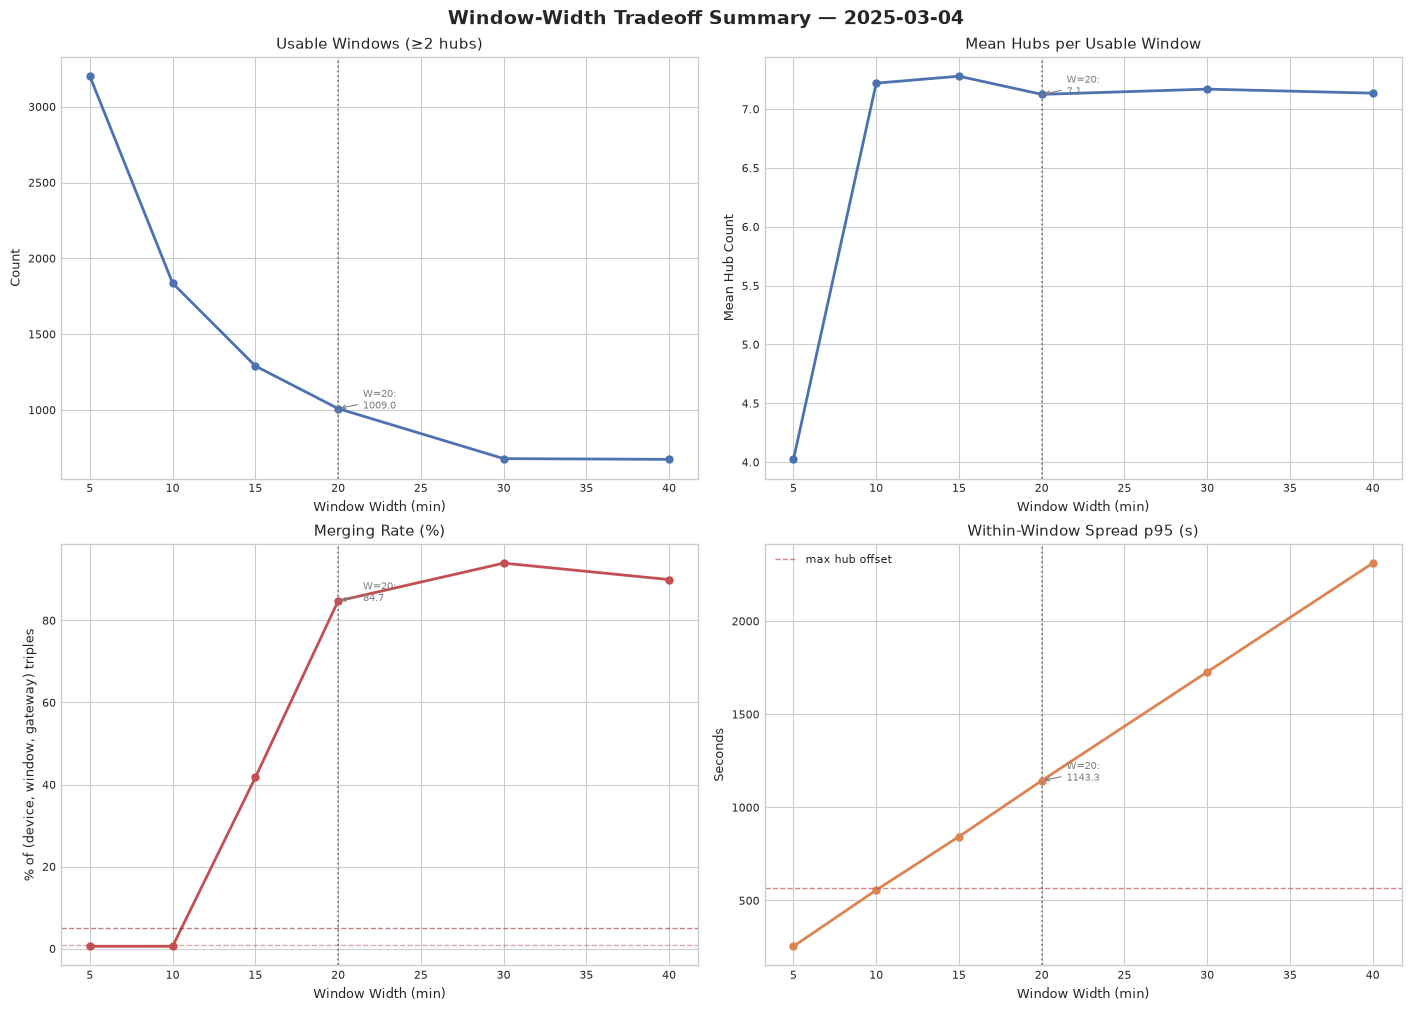

Saved: 04_tradeoff_summary.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

W = df_results["window_min"]

_title_fs  = 11
_label_fs  = 9
_tick_fs   = 8
_annot_col = "gray"

def _mark_w20(ax, y_val, y_label):
    ax.axvline(20, color="gray", linestyle=":", linewidth=1.3)
    ax.annotate(
        f"W=20:\n{y_val:.1f}",
        xy=(20, y_val),
        xytext=(21.5, y_val),
        fontsize=7, color="gray",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

# Panel 1: Usable windows
ax = axes[0, 0]
ax.plot(W, df_results["usable_windows"], color="#4C72B0", linewidth=2,
        marker="o", markersize=5)
_mark_w20(ax, row20["usable_windows"], "usable_windows")
ax.set_title("Usable Windows (\u22652 hubs)", fontsize=_title_fs)
ax.set_xlabel("Window Width (min)", fontsize=_label_fs)
ax.set_ylabel("Count", fontsize=_label_fs)
ax.tick_params(labelsize=_tick_fs)

# Panel 2: Mean hubs
ax = axes[0, 1]
ax.plot(W, df_results["mean_hubs"], color="#4C72B0", linewidth=2,
        marker="o", markersize=5)
_mark_w20(ax, row20["mean_hubs"], "mean_hubs")
ax.set_title("Mean Hubs per Usable Window", fontsize=_title_fs)
ax.set_xlabel("Window Width (min)", fontsize=_label_fs)
ax.set_ylabel("Mean Hub Count", fontsize=_label_fs)
ax.tick_params(labelsize=_tick_fs)

# Panel 3: Merging rate
ax = axes[1, 0]
ax.plot(W, df_results["merging_rate"], color="#C44E52", linewidth=2,
        marker="o", markersize=5)
ax.axhline(1.0, color="#C44E52", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(5.0, color="#8B0000",  linestyle="--", linewidth=1, alpha=0.5)
_mark_w20(ax, row20["merging_rate"], "merging_rate")
ax.set_title("Merging Rate (%)", fontsize=_title_fs)
ax.set_xlabel("Window Width (min)", fontsize=_label_fs)
ax.set_ylabel("% of (device, window, gateway) triples", fontsize=_label_fs)
ax.tick_params(labelsize=_tick_fs)

# Panel 4: Spread p95
ax = axes[1, 1]
ax.plot(W, df_results["spread_p95"], color="#DD8452", linewidth=2,
        marker="o", markersize=5)
ax.axhline(565, color="#C44E52", linestyle="--", linewidth=1, alpha=0.7,
           label="max hub offset")
_mark_w20(ax, row20["spread_p95"], "spread_p95")
ax.set_title("Within-Window Spread p95 (s)", fontsize=_title_fs)
ax.set_xlabel("Window Width (min)", fontsize=_label_fs)
ax.set_ylabel("Seconds", fontsize=_label_fs)
ax.tick_params(labelsize=_tick_fs)
ax.legend(fontsize=8)

fig.suptitle(
    f"Window-Width Tradeoff Summary — {ANALYSIS_DATE}",
    fontsize=14,
    fontweight="bold",
)
plt.savefig(OUTPUT_DIR / "04_tradeoff_summary.png", dpi=150)
plt.show()
print("Saved: 04_tradeoff_summary.png")

<a id="section-3"></a>
## Section 3 — Findings & Recommendations

*This section contains only markdown cells. Fill in the placeholders after the notebook has been run against real data.*

### 3.1 — Summary of Thread 1 Findings

<!-- TODO: fill in after running -->

- **Hub cadence:** observed median gap = **X s** (expected 600 s). Assessment: [stable / unstable].
- **Phase stability:** [all hubs show horizontal bands / hub X shows drift].
- **Offset population:** distribution is [approximately uniform / clustered]. Maximum pairwise spread observed: **X s**.
- **20-min window justification:** [confirmed / needs revision]. The window provides a **X×** safety margin over the observed p99 spread.

### 3.2 — Summary of Thread 2 Findings

<!-- TODO: fill in after running -->

- **Coverage peaks** at W=**X** min with **Y** usable windows.
- **Merging rate first exceeds 1%** at W=**X** min.
- **The defensible window band** based on coverage/merging crossover is [W_min, W_max] minutes.
- **Current config (W=20) sits** [within / outside] this band.

### 3.3 — Open Questions & Next Steps

- [ ] Confirm hub cadence against firmware documentation (currently inferred from empirical gaps).
- [ ] Extend sweep to one week of data to check day-of-week variation.
- [ ] Prototype de-skewed bucketing (Thread 3 from `windowing_reassessment.md`).
- [ ] Prototype gap-based sessionization (Thread 3).
- [ ] Implement confidence scoring per window (Thread 4).
- [ ] Assess whether `WINDOW_TOLERANCE_MINUTES` in `config.py` should be promoted to a real tolerance parameter or made obsolete by de-skewing.

---

⚠️ **Clear all outputs before committing** — query results contain real device identifiers.

Run:
```bash
jupyter nbconvert --clear-output --inplace analysis/04_windowing_reassessment.ipynb
```